# TAAC Dataset EDA

This notebook reads the latest prepared output directory and visualizes the current demo dataset audit, split summary, and sequence tensorization results.

In [4]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent

outputs_dir = root / "outputs"
available_output_dirs = sorted(
    [
        path
        for path in outputs_dir.iterdir()
        if path.is_dir() and (path / "reports" / "summary.json").exists()
    ],
    key=lambda path: path.stat().st_mtime,
    reverse=True,
)
if not available_output_dirs:
    raise FileNotFoundError("No prepared output directory with reports was found under outputs/.")

output_dir = available_output_dirs[0]
reports_dir = output_dir / "reports"

def load_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))

summary = load_json(reports_dir / "summary.json")
audit = load_json(reports_dir / "audit.json")
cleaning = load_json(reports_dir / "cleaning.json")
split_summary = load_json(reports_dir / "split_summary.json")
sequence_tensorization = load_json(reports_dir / "sequence_tensorization.json")
model_input_spec_path = reports_dir / "model_input_spec.json"
model_input_spec = load_json(model_input_spec_path) if model_input_spec_path.exists() else None
prepared = pd.read_parquet(output_dir / "prepared.parquet")
cleaned = pd.read_parquet(output_dir / "cleaned.parquet")

print(f"Using output directory: {output_dir}")
print(f"Prepared shape: {prepared.shape}")
print(f"Cleaned shape: {cleaned.shape}")
if model_input_spec is not None:
    print(f"Sequence preset: {model_input_spec['sequence_length_configuration']['preset']}")

Using output directory: D:\files\aaa\推荐系统\TAAC\datasets\outputs\prepared_balanced_preset
Prepared shape: (1000, 277)
Cleaned shape: (1000, 120)
Sequence preset: balanced


In [2]:
overview = pd.DataFrame(
    [
        {"metric": "rows", "value": summary["rows"]},
        {"metric": "columns", "value": summary["columns"]},
        {"metric": "unique_users", "value": audit["unique_users"]},
        {"metric": "unique_items", "value": audit["unique_items"]},
        {"metric": "duplicate_rows", "value": audit["duplicate_rows"]},
        {"metric": "cleaned_rows", "value": cleaning["output_rows"]},
        {"metric": "sequence_columns", "value": sequence_tensorization["sequence_group_count"]},
    ]
)
display(overview)
display(pd.DataFrame([summary["feature_groups"]]))

,metric,value
0,rows,1000
1,columns,120
2,unique_users,1000
3,unique_items,837
4,duplicate_rows,0
5,cleaned_rows,1000
6,sequence_columns,45


,id_and_label,user_int,user_dense,item_int,domain_a_seq,domain_b_seq,domain_c_seq,domain_d_seq
0,5,46,10,14,9,14,12,10


In [13]:
if model_input_spec is None:
    raise FileNotFoundError("model_input_spec.json was not found in the current reports directory.")

model_input_overview = pd.DataFrame(
    [
        {
            "metric": "sequence_preset",
            "value": model_input_spec["sequence_length_configuration"]["preset"] or "custom",
        },
        {
            "metric": "scalar_features",
            "value": len(model_input_spec["feature_layout"]["scalar_columns"]),
        },
        {
            "metric": "ragged_features",
            "value": len(model_input_spec["feature_layout"]["ragged_feature_inputs"]),
        },
        {
            "metric": "sequence_inputs",
            "value": len(model_input_spec["feature_layout"]["sequence_inputs"]),
        },
        {
            "metric": "prepared_columns",
            "value": model_input_spec["prepared_layout"]["columns"],
        },
    ]
)
display(model_input_overview)

preset_df = pd.DataFrame(model_input_spec["sequence_length_configuration"]["available_presets"]).T
preset_df["description"] = preset_df.index.map(
    model_input_spec["sequence_length_configuration"]["preset_descriptions"].get
)
display(preset_df)

,metric,value
0,sequence_preset,balanced
1,scalar_features,48
2,ragged_features,22
3,sequence_inputs,45
4,prepared_columns,277


,domain_a_seq,domain_b_seq,domain_c_seq,domain_d_seq,description
compact,128,128,256,256,Lower-memory preset for quick experiments with...
balanced,256,256,512,1024,Recommended preset that relaxes truncation for...
long_context,512,512,1024,1536,Long-history preset for offline experiments th...


In [18]:
import sys

if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from taac_training_inputs import PreparedModelInputDataset, summarize_model_input_batch

train_path = output_dir / "train.parquet"
if train_path.exists() and model_input_spec is not None:
    model_input_dataset = PreparedModelInputDataset.from_paths(
        train_path,
        model_input_spec_path,
    )
    batch_preview = summarize_model_input_batch(
        next(model_input_dataset.iter_batches(batch_size=4))
    )
    batch_overview = pd.DataFrame(
        [
            {"metric": "dataset_rows", "value": len(model_input_dataset)},
            {"metric": "batch_size", "value": batch_preview["batch_size"]},
            {"metric": "first_sequence_name", "value": batch_preview["first_sequence_feature"]["name"]},
            {"metric": "first_sequence_shape", "value": tuple(batch_preview["first_sequence_feature"]["values_shape"])},
            {"metric": "first_ragged_name", "value": batch_preview["first_ragged_feature"]["name"]},
        ]
    )
    display(batch_overview)
else:
    print("train.parquet or model_input_spec.json was not found; batch preview skipped.")

,metric,value
0,dataset_rows,800
1,batch_size,4
2,first_sequence_name,domain_a_seq_38
3,first_sequence_shape,"(4, 256)"
4,first_ragged_name,user_int_feats_15


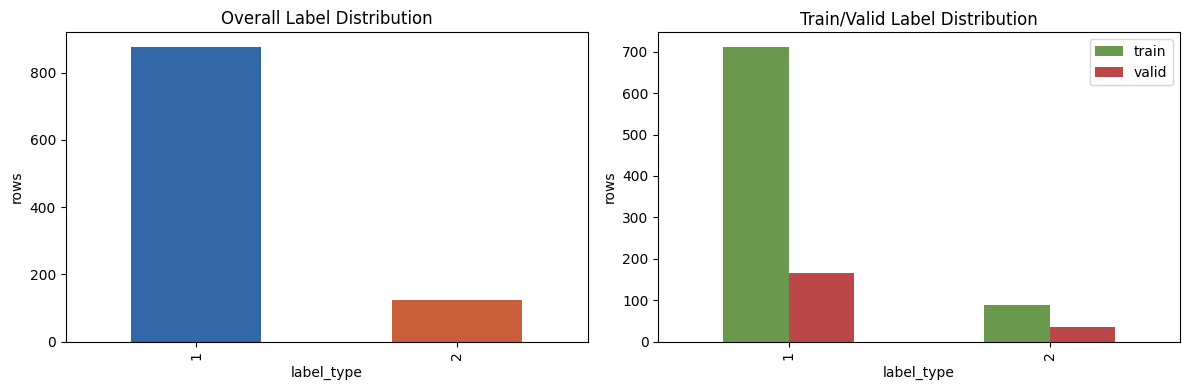

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_counts = pd.Series(audit["label_distribution"]).sort_index()
label_counts.plot(kind="bar", ax=axes[0], color=["#3268a8", "#c95f3c"])
axes[0].set_title("Overall Label Distribution")
axes[0].set_xlabel("label_type")
axes[0].set_ylabel("rows")

split_label_df = pd.DataFrame(
    {
        split_name: pd.Series(split_payload["label_distribution"])
        for split_name, split_payload in split_summary.items()
    }
).fillna(0).astype(int).sort_index()
split_label_df.plot(kind="bar", ax=axes[1], color=["#6a994e", "#bc4749"])
axes[1].set_title("Train/Valid Label Distribution")
axes[1].set_xlabel("label_type")
axes[1].set_ylabel("rows")

plt.tight_layout()
plt.show()

,column,domain,target_length,resolved_from,observed_max_length,observed_mean_length,truncated_rows,truncation_rate,empty_rows
0,domain_a_seq_38,domain_a,256,domain_a_seq,1888,701.086,719,0.719,5
1,domain_a_seq_39,domain_a,256,domain_a_seq,1888,701.086,719,0.719,5
2,domain_a_seq_40,domain_a,256,domain_a_seq,1888,701.086,719,0.719,5
3,domain_a_seq_41,domain_a,256,domain_a_seq,1888,701.086,719,0.719,5
4,domain_a_seq_42,domain_a,256,domain_a_seq,1888,701.086,719,0.719,5
5,domain_a_seq_43,domain_a,256,domain_a_seq,1888,701.086,719,0.719,5
6,domain_a_seq_44,domain_a,256,domain_a_seq,1888,701.086,719,0.719,5
7,domain_a_seq_45,domain_a,256,domain_a_seq,1888,701.086,719,0.719,5
8,domain_a_seq_46,domain_a,256,domain_a_seq,1888,701.086,719,0.719,5
9,domain_b_seq_67,domain_b,256,domain_b_seq,1952,570.758,624,0.624,12


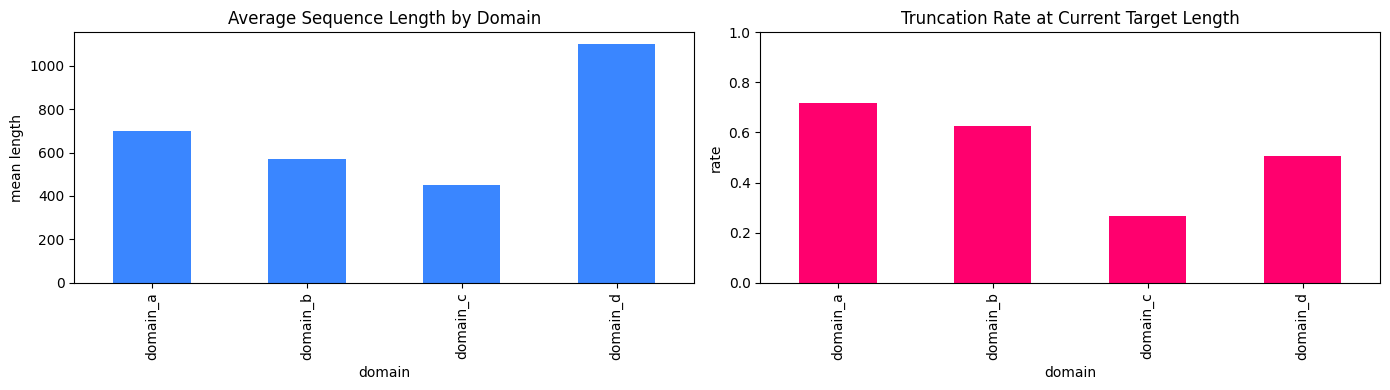

In [14]:
sequence_rows = []
for column_name, payload in sequence_tensorization["sequence_columns"].items():
    sequence_rows.append(
        {
            "column": column_name,
            "domain": column_name.split("_seq_")[0],
            "target_length": payload["target_length"],
            "resolved_from": payload.get("resolved_from", "default"),
            "observed_max_length": payload["observed_max_length"],
            "observed_mean_length": payload["observed_mean_length"],
            "truncated_rows": payload["truncated_rows"],
            "truncation_rate": round(payload["truncated_rows"] / len(cleaned), 4),
            "empty_rows": payload["empty_rows"],
        }
    )

sequence_df = pd.DataFrame(sequence_rows).sort_values(["domain", "column"]).reset_index(drop=True)
display(sequence_df.head(10))

domain_summary = sequence_df.groupby("domain", as_index=False)[["observed_mean_length", "observed_max_length", "truncation_rate"]].mean()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
domain_summary.plot(x="domain", y="observed_mean_length", kind="bar", ax=axes[0], color="#3a86ff", legend=False)
axes[0].set_title("Average Sequence Length by Domain")
axes[0].set_ylabel("mean length")
axes[0].set_xlabel("domain")

domain_summary.plot(x="domain", y="truncation_rate", kind="bar", ax=axes[1], color="#ff006e", legend=False)
axes[1].set_title("Truncation Rate at Current Target Length")
axes[1].set_ylabel("rate")
axes[1].set_xlabel("domain")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

,domain,candidate_length,truncated_rows,truncation_rate
0,domain_a,50,946.0,0.946
1,domain_a,256,719.0,0.719
2,domain_a,512,541.0,0.541
3,domain_a,1024,288.0,0.288
4,domain_b,50,873.0,0.873
5,domain_b,256,624.0,0.624
6,domain_b,512,434.0,0.434
7,domain_b,1024,210.0,0.210
8,domain_c,50,964.0,0.964
9,domain_c,256,616.0,0.616


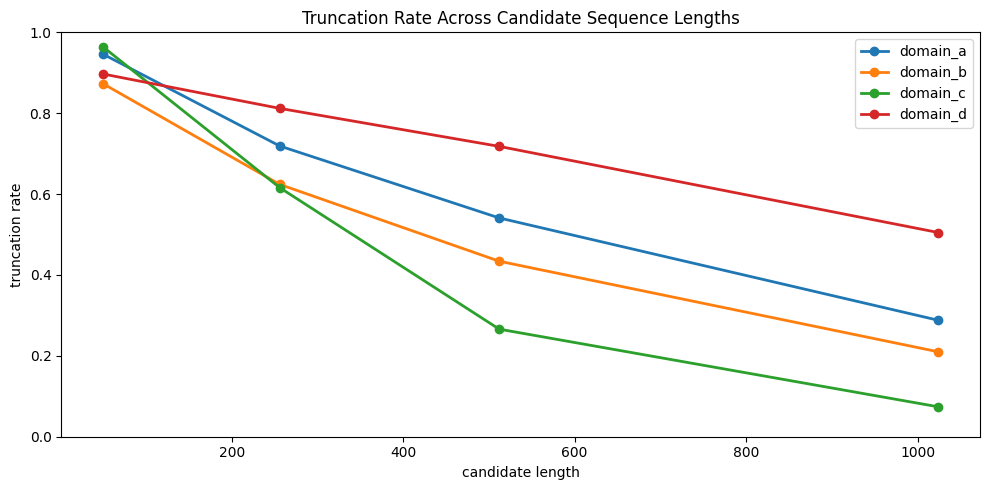

In [15]:
candidate_lengths = sorted(
    {
        sequence_tensorization.get("default_target_length") or 50,
        *sequence_tensorization.get("sequence_length_overrides", {}).values(),
        512,
    }
)

comparison_rows = []
for column_name in sequence_tensorization["sequence_columns"]:
    domain_name = column_name.split("_seq_")[0]
    lengths = cleaned[column_name].map(len)
    for candidate_length in candidate_lengths:
        truncated_rows = int((lengths > candidate_length).sum())
        comparison_rows.append(
            {
                "column": column_name,
                "domain": domain_name,
                "candidate_length": candidate_length,
                "truncated_rows": truncated_rows,
                "truncation_rate": round(truncated_rows / len(cleaned), 4),
            }
        )

length_compare_df = pd.DataFrame(comparison_rows)
domain_length_compare = length_compare_df.groupby(["domain", "candidate_length"], as_index=False)[["truncated_rows", "truncation_rate"]].mean()
display(domain_length_compare)

fig, ax = plt.subplots(figsize=(10, 5))
for domain_name, domain_frame in domain_length_compare.groupby("domain"):
    ax.plot(
        domain_frame["candidate_length"],
        domain_frame["truncation_rate"],
        marker="o",
        linewidth=2,
        label=domain_name,
    )

ax.set_title("Truncation Rate Across Candidate Sequence Lengths")
ax.set_xlabel("candidate length")
ax.set_ylabel("truncation rate")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
sample_columns = list(sequence_tensorization["sequence_columns"].keys())[:3]
sample_rows = []
for column_name in sample_columns:
    payload = sequence_tensorization["sequence_columns"][column_name]
    tensor_column = payload["tensor_column"]
    mask_column = payload["mask_column"]
    length_column = payload["length_column"]
    sample_rows.append(
        {
            "column": column_name,
            "effective_length": int(prepared.loc[0, length_column]),
            "mask_sum": int(sum(prepared.loc[0, mask_column])),
            "tensor_head": prepared.loc[0, tensor_column][:10],
            "mask_head": prepared.loc[0, mask_column][:10],
        }
    )

display(pd.DataFrame(sample_rows))

,column,effective_length,mask_sum,tensor_head,mask_head
0,domain_a_seq_38,256,256,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
1,domain_a_seq_39,256,256,"[1761102120, 1761101340, 1761097860, 176109474...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
2,domain_a_seq_40,256,256,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"


In [11]:
split_overview = pd.DataFrame(
    [
        {
            "split": split_name,
            "rows": payload["rows"],
            "time_min": payload["time_range"]["min"],
            "time_max": payload["time_range"]["max"],
        }
        for split_name, payload in split_summary.items()
    ]
)
display(split_overview)

,split,rows,time_min,time_max
0,train,800,1772725027,1772725686
1,valid,200,1772725687,1772725910


In [2]:
error_analysis_dir = root / "outputs" / "training_runs" / "latest" / "error_analysis"
if not error_analysis_dir.exists():
    raise FileNotFoundError(f"Error analysis directory was not found: {error_analysis_dir}")

error_summary_path = error_analysis_dir / "summary.json"
label_error_path = error_analysis_dir / "label_error_summary.csv"
time_error_path = error_analysis_dir / "time_bucket_error_summary.csv"
activity_error_path = error_analysis_dir / "activity_bucket_error_summary.csv"
high_error_path = error_analysis_dir / "high_confidence_errors.csv"

error_summary = load_json(error_summary_path)
label_error_df = pd.read_csv(label_error_path)
time_error_df = pd.read_csv(time_error_path)
activity_error_df = pd.read_csv(activity_error_path)
high_error_df = pd.read_csv(high_error_path)

display(pd.DataFrame([{
    "error_rows": error_summary["error_rows"],
    "error_rate": error_summary["error_rate"],
    "time_bucket_count": error_summary["time_bucket_count"],
    "activity_bucket_count": error_summary["activity_bucket_count"],
    "activity_definition": error_summary["activity_definition"]["type"],
}]))

,error_rows,error_rate,time_bucket_count,activity_bucket_count,activity_definition
0,35,0.175,4,4,sum_of_domain_history_lengths


,label_type,rows,error_count,avg_confidence,avg_true_label_prob,avg_margin,error_rate
0,1,165,0,0.854249,0.854249,0.708497,0.0
1,2,35,35,0.856324,0.143676,0.712647,1.0


,time_bucket,rows,error_count,avg_confidence,avg_margin,time_min,time_max,error_rate
0,time_1,50,4,0.852747,0.705495,1772725687,1772725719,0.08
1,time_2,50,5,0.857407,0.714814,1772725719,1772725748,0.10
2,time_3,50,6,0.853972,0.707944,1772725750,1772725780,0.12
3,time_4,50,20,0.854321,0.708641,1772725780,1772725910,0.40


,activity_bucket,rows,error_count,avg_confidence,avg_margin,avg_total_history_length,activity_min,activity_max,error_rate
0,activity_1,50,8,0.856640,0.713280,844.52,159,1207,0.16
1,activity_2,50,9,0.855078,0.710156,1423.84,1221,1594,0.18
2,activity_3,50,8,0.853342,0.706684,1743.00,1597,1867,0.16
3,activity_4,50,10,0.853386,0.706773,2007.58,1870,2048,0.20


,user_id,item_id,label_type,label_time,timestamp,predicted_label,prob_label_1,prob_label_2,domain_a_seq_38_len,domain_b_seq_67_len,...,domain_b_history_length,domain_c_history_length,domain_d_history_length,total_history_length,is_error,predicted_confidence,true_label_probability,confidence_margin,time_bucket,activity_bucket
0,2930248,109119327,2,1772725794,1772725729,1,0.870193,0.129807,185,36,...,36,489,0,710,True,0.870193,0.129807,0.740386,time_4,activity_1
1,7871033,112347232,2,1772725698,1772725512,1,0.866720,0.133280,256,256,...,256,512,0,1024,True,0.866720,0.133280,0.733440,time_1,activity_1
2,11124697,265146184,2,1772725819,1772725620,1,0.866128,0.133872,256,152,...,152,161,1024,1593,True,0.866128,0.133872,0.732256,time_4,activity_2
3,5768837,238594337,2,1772725766,1772725413,1,0.865630,0.134370,256,189,...,189,365,1024,1834,True,0.865630,0.134370,0.731259,time_3,activity_3
4,10175985,15944194,2,1772725732,1772725009,1,0.863198,0.136802,256,256,...,256,512,1024,2048,True,0.863198,0.136802,0.726396,time_2,activity_4
5,10995344,177426736,2,1772725704,1772725196,1,0.863079,0.136921,256,256,...,256,436,1024,1972,True,0.863079,0.136921,0.726158,time_1,activity_4
6,10446422,126753912,2,1772725854,1772725022,1,0.862832,0.137168,256,256,...,256,508,0,1020,True,0.862832,0.137168,0.725664,time_4,activity_1
7,11844890,153499507,2,1772725851,1772725218,1,0.861807,0.138193,256,256,...,256,512,1024,2048,True,0.861807,0.138193,0.723614,time_4,activity_4
8,8745995,98021883,2,1772725756,1772725437,1,0.861343,0.138657,256,256,...,256,284,620,1416,True,0.861343,0.138657,0.722686,time_3,activity_2
9,11987994,114472465,2,1772725799,1772725084,1,0.859949,0.140051,256,256,...,256,297,513,1322,True,0.859949,0.140051,0.719898,time_4,activity_2


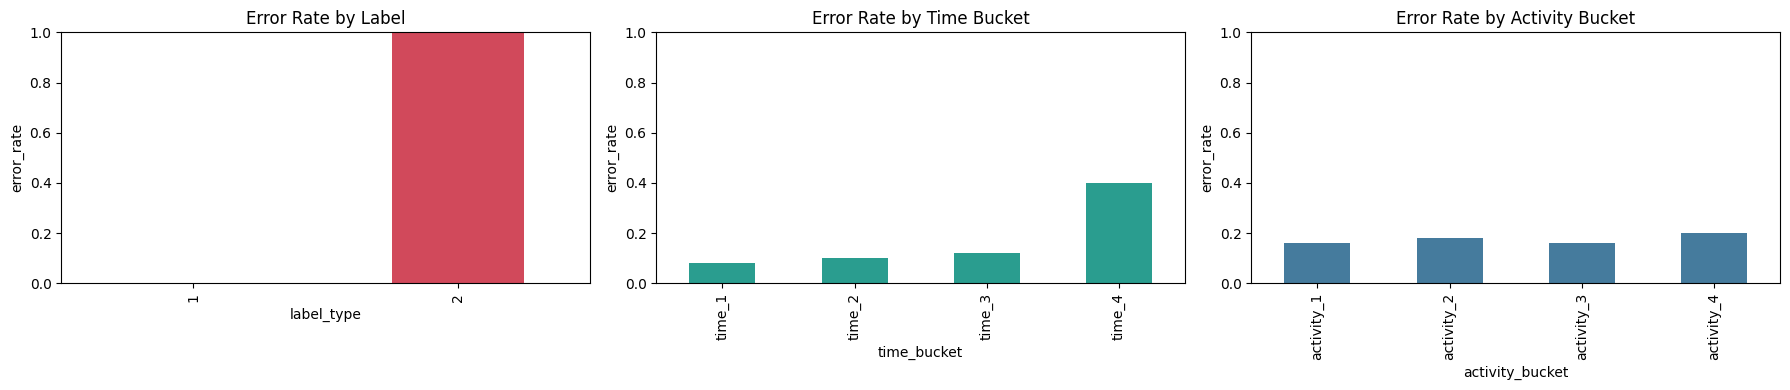

In [3]:
display(label_error_df)
display(time_error_df)
display(activity_error_df)
display(high_error_df.head(10))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

label_error_df.plot(x="label_type", y="error_rate", kind="bar", ax=axes[0], color="#d1495b", legend=False)
axes[0].set_title("Error Rate by Label")
axes[0].set_xlabel("label_type")
axes[0].set_ylabel("error_rate")
axes[0].set_ylim(0, 1)

ordered_time_df = time_error_df.copy()
ordered_time_df["bucket_index"] = ordered_time_df["time_bucket"].str.extract(r"(\d+)").astype(int)
ordered_time_df = ordered_time_df.sort_values("bucket_index")
ordered_time_df.plot(x="time_bucket", y="error_rate", kind="bar", ax=axes[1], color="#2a9d8f", legend=False)
axes[1].set_title("Error Rate by Time Bucket")
axes[1].set_xlabel("time_bucket")
axes[1].set_ylabel("error_rate")
axes[1].set_ylim(0, 1)

ordered_activity_df = activity_error_df.copy()
ordered_activity_df["bucket_index"] = ordered_activity_df["activity_bucket"].str.extract(r"(\d+)").astype(int)
ordered_activity_df = ordered_activity_df.sort_values("bucket_index")
ordered_activity_df.plot(x="activity_bucket", y="error_rate", kind="bar", ax=axes[2], color="#457b9d", legend=False)
axes[2].set_title("Error Rate by Activity Bucket")
axes[2].set_xlabel("activity_bucket")
axes[2].set_ylabel("error_rate")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 全量数据画像（列级别）

这一部分从原始 `demo_1000.parquet` 出发，生成**每一列**的属性说明与统计信息，帮助你直观理解数据结构与分布特征。

In [5]:
import numpy as np

raw_path = root / "demo_1000.parquet"
if not raw_path.exists():
    raise FileNotFoundError(f"Raw dataset not found: {raw_path}")

raw_df = pd.read_parquet(raw_path)


def infer_category(column_name: str) -> str:
    if column_name in {"user_id", "item_id"}:
        return "id"
    if column_name == "label_type":
        return "label"
    if column_name in {"label_time", "timestamp"}:
        return "time"
    if column_name.startswith("user_int_feats_"):
        return "user_int"
    if column_name.startswith("user_dense_feats_"):
        return "user_dense"
    if column_name.startswith("item_int_feats_"):
        return "item_int"
    if column_name.startswith("domain_a_seq_"):
        return "domain_a_seq"
    if column_name.startswith("domain_b_seq_"):
        return "domain_b_seq"
    if column_name.startswith("domain_c_seq_"):
        return "domain_c_seq"
    if column_name.startswith("domain_d_seq_"):
        return "domain_d_seq"
    return "other"


def infer_description(column_name: str, category: str) -> str:
    if column_name == "user_id":
        return "用户唯一标识"
    if column_name == "item_id":
        return "物料/内容唯一标识"
    if column_name == "label_type":
        return "监督标签（当前任务二分类标签）"
    if column_name == "label_time":
        return "标签事件时间（用于时序切分）"
    if column_name == "timestamp":
        return "样本记录时间戳"
    if category in {"domain_a_seq", "domain_b_seq", "domain_c_seq", "domain_d_seq"}:
        return f"{category} 域行为序列特征（list<int64>）"
    if category == "user_dense":
        return "用户侧稠密向量特征（list<float>）"
    if category == "user_int":
        return "用户侧离散/计数型特征（int 或 list<int>）"
    if category == "item_int":
        return "物料侧离散/计数型特征（int 或 list<int>）"
    return "未归类特征"


def detect_value_mode(series: pd.Series) -> str:
    sample = None
    for value in series:
        if value is None:
            continue
        if isinstance(value, float) and pd.isna(value):
            continue
        sample = value
        break
    if sample is None:
        return "all_null"
    if isinstance(sample, (list, tuple, np.ndarray)):
        return "list"
    return "scalar"


profile_rows = []
for col in raw_df.columns:
    s = raw_df[col]
    category = infer_category(col)
    value_mode = detect_value_mode(s)
    dtype_str = str(s.dtype)
    missing_count = int(s.isna().sum()) if value_mode == "scalar" else int(sum(v is None for v in s))
    missing_ratio = round(missing_count / len(raw_df), 6)

    row = {
        "column": col,
        "category": category,
        "description": infer_description(col, category),
        "dtype": dtype_str,
        "value_mode": value_mode,
        "rows": int(len(s)),
        "missing_count": missing_count,
        "missing_ratio": missing_ratio,
        "unique_count": None,
        "min": None,
        "max": None,
        "mean": None,
        "std": None,
        "len_mean": None,
        "len_p95": None,
        "len_max": None,
        "example": None,
    }

    if value_mode == "scalar":
        row["unique_count"] = int(s.nunique(dropna=True))
        numeric = pd.to_numeric(s, errors="coerce")
        if numeric.notna().any():
            row["min"] = float(numeric.min())
            row["max"] = float(numeric.max())
            row["mean"] = float(numeric.mean())
            row["std"] = float(numeric.std(ddof=0))
        non_null = s.dropna()
        row["example"] = None if non_null.empty else str(non_null.iloc[0])
    else:
        lengths = s.map(lambda x: len(x) if isinstance(x, (list, tuple, np.ndarray)) else 0)
        row["len_mean"] = float(lengths.mean())
        row["len_p95"] = float(lengths.quantile(0.95))
        row["len_max"] = int(lengths.max())
        first_list = next((x for x in s if isinstance(x, (list, tuple, np.ndarray)) and len(x) > 0), [])
        row["example"] = str(list(first_list)[:8])

    profile_rows.append(row)

column_profile_df = pd.DataFrame(profile_rows).sort_values(["category", "column"]).reset_index(drop=True)

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 30)
display(column_profile_df)

column_profile_path = root / "outputs" / "column_profile.csv"
column_profile_path.parent.mkdir(parents=True, exist_ok=True)
column_profile_df.to_csv(column_profile_path, index=False, encoding="utf-8-sig")
print(f"列级画像已保存: {column_profile_path}")

,column,category,description,dtype,value_mode,rows,missing_count,missing_ratio,unique_count,min,max,mean,std,len_mean,len_p95,len_max,example
0,domain_a_seq_38,domain_a_seq,domain_a_seq 域行为序列特征（list<int64>）,object,list,1000,5,0.005,NaN,NaN,NaN,NaN,NaN,701.086,1673.15,1888.0,"[np.int64(0), np.int64(0), np.int64(0), np.int..."
1,domain_a_seq_39,domain_a_seq,domain_a_seq 域行为序列特征（list<int64>）,object,list,1000,5,0.005,NaN,NaN,NaN,NaN,NaN,701.086,1673.15,1888.0,"[np.int64(1772695320), np.int64(1772626560), n..."
2,domain_a_seq_40,domain_a_seq,domain_a_seq 域行为序列特征（list<int64>）,object,list,1000,5,0.005,NaN,NaN,NaN,NaN,NaN,701.086,1673.15,1888.0,"[np.int64(2), np.int64(2), np.int64(7), np.int..."
3,domain_a_seq_41,domain_a_seq,domain_a_seq 域行为序列特征（list<int64>）,object,list,1000,5,0.005,NaN,NaN,NaN,NaN,NaN,701.086,1673.15,1888.0,"[np.int64(6), np.int64(6), np.int64(11), np.in..."
4,domain_a_seq_42,domain_a_seq,domain_a_seq 域行为序列特征（list<int64>）,object,list,1000,5,0.005,NaN,NaN,NaN,NaN,NaN,701.086,1673.15,1888.0,"[np.int64(840), np.int64(840), np.int64(0), np..."
5,domain_a_seq_43,domain_a_seq,domain_a_seq 域行为序列特征（list<int64>）,object,list,1000,5,0.005,NaN,NaN,NaN,NaN,NaN,701.086,1673.15,1888.0,"[np.int64(1365), np.int64(2046), np.int64(0), ..."
6,domain_a_seq_44,domain_a_seq,domain_a_seq 域行为序列特征（list<int64>）,object,list,1000,5,0.005,NaN,NaN,NaN,NaN,NaN,701.086,1673.15,1888.0,"[np.int64(3792), np.int64(5577), np.int64(0), ..."
7,domain_a_seq_45,domain_a_seq,domain_a_seq 域行为序列特征（list<int64>）,object,list,1000,5,0.005,NaN,NaN,NaN,NaN,NaN,701.086,1673.15,1888.0,"[np.int64(0), np.int64(0), np.int64(0), np.int..."
8,domain_a_seq_46,domain_a_seq,domain_a_seq 域行为序列特征（list<int64>）,object,list,1000,5,0.005,NaN,NaN,NaN,NaN,NaN,701.086,1673.15,1888.0,"[np.int64(12), np.int64(1), np.int64(0), np.in..."
9,domain_b_seq_67,domain_b_seq,domain_b_seq 域行为序列特征（list<int64>）,object,list,1000,12,0.012,NaN,NaN,NaN,NaN,NaN,570.758,1563.15,1952.0,"[np.int64(1772720154), np.int64(1772705768), n..."


列级画像已保存: D:\files\aaa\推荐系统\TAAC\datasets\outputs\column_profile.csv


,category,columns,avg_missing_ratio,scalar_columns,list_columns
9,user_int,46,0.282739,35,11
1,domain_b_seq,14,0.012000,0,14
5,item_int,14,0.211071,13,1
2,domain_c_seq,12,0.002000,0,12
8,user_dense,10,0.098900,0,10
3,domain_d_seq,10,0.080000,0,10
0,domain_a_seq,9,0.005000,0,9
4,id,2,0.000000,2,0
7,time,2,0.000000,2,0
6,label,1,0.000000,1,0


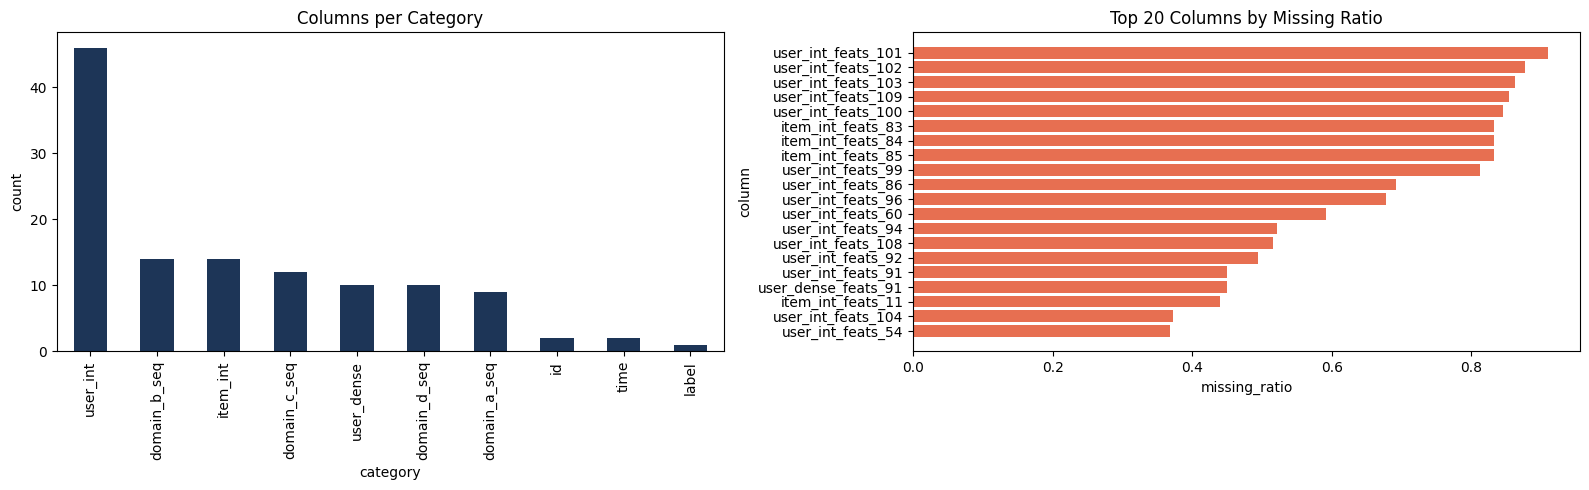

标量列数量: 53
列表列数量: 67


In [6]:
category_summary_df = (
    column_profile_df.groupby("category", as_index=False)
    .agg(
        columns=("column", "count"),
        avg_missing_ratio=("missing_ratio", "mean"),
        scalar_columns=("value_mode", lambda x: int((x == "scalar").sum())),
        list_columns=("value_mode", lambda x: int((x == "list").sum())),
    )
    .sort_values("columns", ascending=False)
)
display(category_summary_df)

scalar_stats_df = column_profile_df[column_profile_df["value_mode"] == "scalar"].copy()
scalar_stats_df["mean_abs"] = scalar_stats_df["mean"].abs()
scalar_stats_df = scalar_stats_df.sort_values("mean_abs", ascending=False)

top_missing_df = column_profile_df.sort_values("missing_ratio", ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
category_summary_df.plot(
    x="category",
    y="columns",
    kind="bar",
    ax=axes[0],
    color="#1d3557",
    legend=False,
)
axes[0].set_title("Columns per Category")
axes[0].set_xlabel("category")
axes[0].set_ylabel("count")

plot_df = top_missing_df.sort_values("missing_ratio", ascending=True)
axes[1].barh(plot_df["column"], plot_df["missing_ratio"], color="#e76f51")
axes[1].set_title("Top 20 Columns by Missing Ratio")
axes[1].set_xlabel("missing_ratio")
axes[1].set_ylabel("column")

plt.tight_layout()
plt.show()

print("标量列数量:", int((column_profile_df["value_mode"] == "scalar").sum()))
print("列表列数量:", int((column_profile_df["value_mode"] == "list").sum()))

,label_type,domain_a_total_len,domain_b_total_len,domain_c_total_len,domain_d_total_len
0,1,6257.527397,7946.566210,5305.273973,10979.394977
1,2,6678.870968,8301.774194,6014.129032,11134.193548


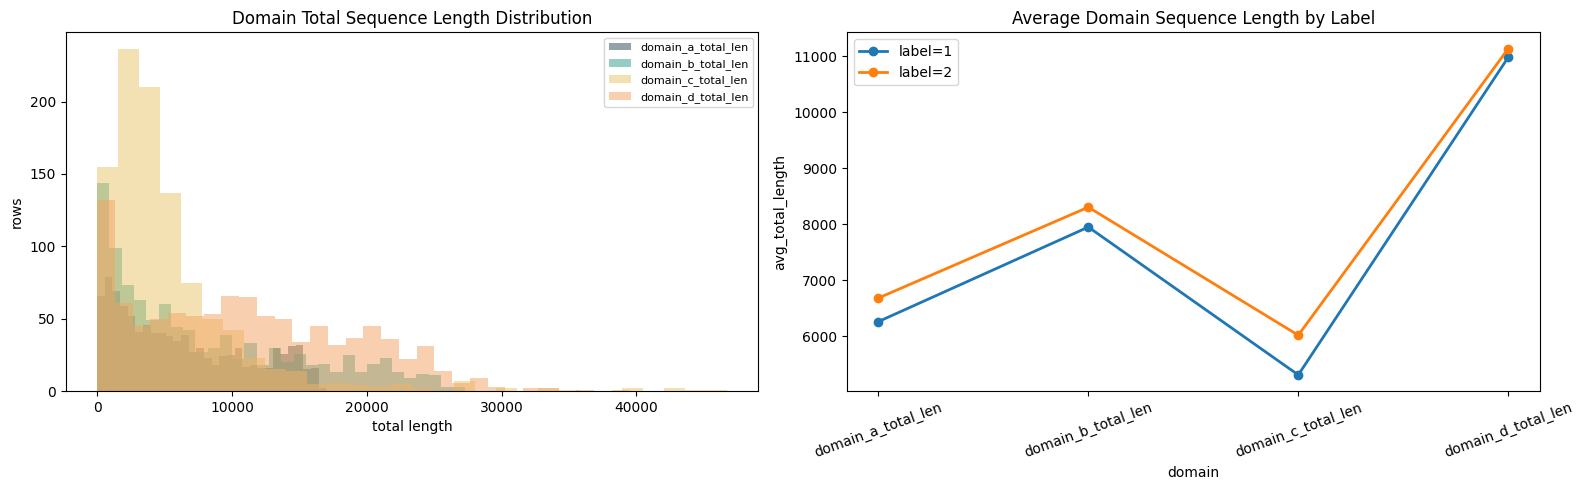

In [7]:
sequence_len_cols = [
    c
    for c in raw_df.columns
    if c.startswith(("domain_a_seq_", "domain_b_seq_", "domain_c_seq_", "domain_d_seq_"))
]

sequence_length_df = pd.DataFrame(index=raw_df.index)
for col in sequence_len_cols:
    sequence_length_df[col] = raw_df[col].map(
        lambda x: len(x) if isinstance(x, (list, tuple, np.ndarray)) else 0
    )

sequence_length_df["label_type"] = raw_df["label_type"].values
sequence_length_df["domain_a_total_len"] = sequence_length_df[[c for c in sequence_len_cols if c.startswith("domain_a_seq_")]].sum(axis=1)
sequence_length_df["domain_b_total_len"] = sequence_length_df[[c for c in sequence_len_cols if c.startswith("domain_b_seq_")]].sum(axis=1)
sequence_length_df["domain_c_total_len"] = sequence_length_df[[c for c in sequence_len_cols if c.startswith("domain_c_seq_")]].sum(axis=1)
sequence_length_df["domain_d_total_len"] = sequence_length_df[[c for c in sequence_len_cols if c.startswith("domain_d_seq_")]].sum(axis=1)

label_seq_summary = (
    sequence_length_df.groupby("label_type", as_index=False)[
        ["domain_a_total_len", "domain_b_total_len", "domain_c_total_len", "domain_d_total_len"]
    ]
    .mean()
)
display(label_seq_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for domain_col, color in zip(
    ["domain_a_total_len", "domain_b_total_len", "domain_c_total_len", "domain_d_total_len"],
    ["#264653", "#2a9d8f", "#e9c46a", "#f4a261"],
):
    axes[0].hist(sequence_length_df[domain_col], bins=30, alpha=0.5, label=domain_col, color=color)
axes[0].set_title("Domain Total Sequence Length Distribution")
axes[0].set_xlabel("total length")
axes[0].set_ylabel("rows")
axes[0].legend(fontsize=8)

label_seq_melt = label_seq_summary.melt(
    id_vars="label_type",
    var_name="domain",
    value_name="avg_total_length",
)
for label_value, frame in label_seq_melt.groupby("label_type"):
    axes[1].plot(
        frame["domain"],
        frame["avg_total_length"],
        marker="o",
        linewidth=2,
        label=f"label={label_value}",
    )
axes[1].set_title("Average Domain Sequence Length by Label")
axes[1].set_xlabel("domain")
axes[1].set_ylabel("avg_total_length")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend()

plt.tight_layout()
plt.show()

## 导出可读版数据字典（Markdown）

将列级画像按类别分组导出为 Markdown 报告，便于汇报与文档沉淀。

In [9]:
from datetime import datetime

if "column_profile_df" not in globals():
    fallback_profile = root / "outputs" / "column_profile.csv"
    if not fallback_profile.exists():
        raise FileNotFoundError("column_profile_df 不存在，且 outputs/column_profile.csv 未找到。请先执行列级画像单元。")
    column_profile_df = pd.read_csv(fallback_profile)

report_path = root / "outputs" / "column_profile_readable.md"
report_path.parent.mkdir(parents=True, exist_ok=True)

report_df = column_profile_df.copy()
for col in ["missing_ratio", "mean", "std", "len_mean", "len_p95"]:
    if col in report_df.columns:
        report_df[col] = pd.to_numeric(report_df[col], errors="coerce").round(6)


def _markdown_escape(value):
    if pd.isna(value):
        return ""
    text = str(value)
    text = text.replace("|", "\\|")
    text = text.replace("\n", " ")
    return text


def _df_to_markdown_table(df: pd.DataFrame) -> str:
    if df.empty:
        return "(empty table)"
    headers = [str(c) for c in df.columns]
    lines = []
    lines.append("| " + " | ".join(headers) + " |")
    lines.append("| " + " | ".join(["---"] * len(headers)) + " |")
    for _, row in df.iterrows():
        lines.append("| " + " | ".join(_markdown_escape(row[c]) for c in df.columns) + " |")
    return "\n".join(lines)


summary_lines = []
summary_lines.append("# TAAC 数据集列级画像报告")
summary_lines.append("")
summary_lines.append(f"- 生成时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
summary_lines.append(f"- 数据行数: {len(raw_df) if 'raw_df' in globals() else 'unknown'}")
summary_lines.append(f"- 列数: {len(report_df)}")
summary_lines.append(f"- 标量列: {int((report_df['value_mode'] == 'scalar').sum())}")
summary_lines.append(f"- 列表列: {int((report_df['value_mode'] == 'list').sum())}")
summary_lines.append("")

cat_summary = (
    report_df.groupby("category", as_index=False)
    .agg(
        columns=("column", "count"),
        avg_missing_ratio=("missing_ratio", "mean"),
        scalar_columns=("value_mode", lambda x: int((x == "scalar").sum())),
        list_columns=("value_mode", lambda x: int((x == "list").sum())),
    )
    .sort_values("columns", ascending=False)
)
summary_lines.append("## 类别概览")
summary_lines.append("")
summary_lines.append(_df_to_markdown_table(cat_summary))
summary_lines.append("")

cols_to_show = [
    "column",
    "description",
    "dtype",
    "value_mode",
    "missing_ratio",
    "unique_count",
    "min",
    "max",
    "mean",
    "std",
    "len_mean",
    "len_p95",
    "len_max",
    "example",
]
valid_cols = [c for c in cols_to_show if c in report_df.columns]

for category, frame in report_df.groupby("category", sort=True):
    summary_lines.append(f"## 类别: {category}")
    summary_lines.append("")
    summary_lines.append(f"- 列数: {len(frame)}")
    summary_lines.append(f"- 平均缺失率: {frame['missing_ratio'].mean():.6f}")
    summary_lines.append("")
    table_df = frame[valid_cols].sort_values("column").copy()
    summary_lines.append(_df_to_markdown_table(table_df))
    summary_lines.append("")

report_path.write_text("\n".join(summary_lines), encoding="utf-8")
print(f"可读版数据字典已导出: {report_path}")

display(cat_summary)
display(report_df.head(10))

可读版数据字典已导出: D:\files\aaa\推荐系统\TAAC\datasets\outputs\column_profile_readable.md


,category,columns,avg_missing_ratio,scalar_columns,list_columns
9,user_int,46,0.282739,35,11
1,domain_b_seq,14,0.012000,0,14
5,item_int,14,0.211071,13,1
2,domain_c_seq,12,0.002000,0,12
8,user_dense,10,0.098900,0,10
3,domain_d_seq,10,0.080000,0,10
0,domain_a_seq,9,0.005000,0,9
4,id,2,0.000000,2,0
7,time,2,0.000000,2,0
6,label,1,0.000000,1,0


,column,category,description,dtype,value_mode,rows,missing_count,missing_ratio,unique_count,min,max,mean,std,len_mean,len_p95,len_max,example
0,domain_a_seq_38,domain_a_seq,domain_a_seq 域行为序列特征（list<int64>）,object,list,1000,5,0.005,NaN,NaN,NaN,NaN,NaN,701.086,1673.15,1888.0,"[np.int64(0), np.int64(0), np.int64(0), np.int..."
1,domain_a_seq_39,domain_a_seq,domain_a_seq 域行为序列特征（list<int64>）,object,list,1000,5,0.005,NaN,NaN,NaN,NaN,NaN,701.086,1673.15,1888.0,"[np.int64(1772695320), np.int64(1772626560), n..."
2,domain_a_seq_40,domain_a_seq,domain_a_seq 域行为序列特征（list<int64>）,object,list,1000,5,0.005,NaN,NaN,NaN,NaN,NaN,701.086,1673.15,1888.0,"[np.int64(2), np.int64(2), np.int64(7), np.int..."
3,domain_a_seq_41,domain_a_seq,domain_a_seq 域行为序列特征（list<int64>）,object,list,1000,5,0.005,NaN,NaN,NaN,NaN,NaN,701.086,1673.15,1888.0,"[np.int64(6), np.int64(6), np.int64(11), np.in..."
4,domain_a_seq_42,domain_a_seq,domain_a_seq 域行为序列特征（list<int64>）,object,list,1000,5,0.005,NaN,NaN,NaN,NaN,NaN,701.086,1673.15,1888.0,"[np.int64(840), np.int64(840), np.int64(0), np..."
5,domain_a_seq_43,domain_a_seq,domain_a_seq 域行为序列特征（list<int64>）,object,list,1000,5,0.005,NaN,NaN,NaN,NaN,NaN,701.086,1673.15,1888.0,"[np.int64(1365), np.int64(2046), np.int64(0), ..."
6,domain_a_seq_44,domain_a_seq,domain_a_seq 域行为序列特征（list<int64>）,object,list,1000,5,0.005,NaN,NaN,NaN,NaN,NaN,701.086,1673.15,1888.0,"[np.int64(3792), np.int64(5577), np.int64(0), ..."
7,domain_a_seq_45,domain_a_seq,domain_a_seq 域行为序列特征（list<int64>）,object,list,1000,5,0.005,NaN,NaN,NaN,NaN,NaN,701.086,1673.15,1888.0,"[np.int64(0), np.int64(0), np.int64(0), np.int..."
8,domain_a_seq_46,domain_a_seq,domain_a_seq 域行为序列特征（list<int64>）,object,list,1000,5,0.005,NaN,NaN,NaN,NaN,NaN,701.086,1673.15,1888.0,"[np.int64(12), np.int64(1), np.int64(0), np.in..."
9,domain_b_seq_67,domain_b_seq,domain_b_seq 域行为序列特征（list<int64>）,object,list,1000,12,0.012,NaN,NaN,NaN,NaN,NaN,570.758,1563.15,1952.0,"[np.int64(1772720154), np.int64(1772705768), n..."
